In [1]:
!pip install -q tensorflow opencv-python pandas scikit-learn matplotlib

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/emotion_data")

In [6]:
import os

print(os.listdir("/content/emotion_data"))

['train', 'test']


In [7]:
print(os.listdir("/content/emotion_data/train"))
print(os.listdir("/content/emotion_data/test"))

['neutral', 'angry', 'sad', 'disgust', 'happy', 'surprise', 'fear']
['neutral', 'angry', 'sad', 'disgust', 'happy', 'surprise', 'fear']


In [8]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_data/train",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    label_mode="categorical"
)

test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_data/test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    label_mode="categorical"
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [9]:
print(train_data.class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


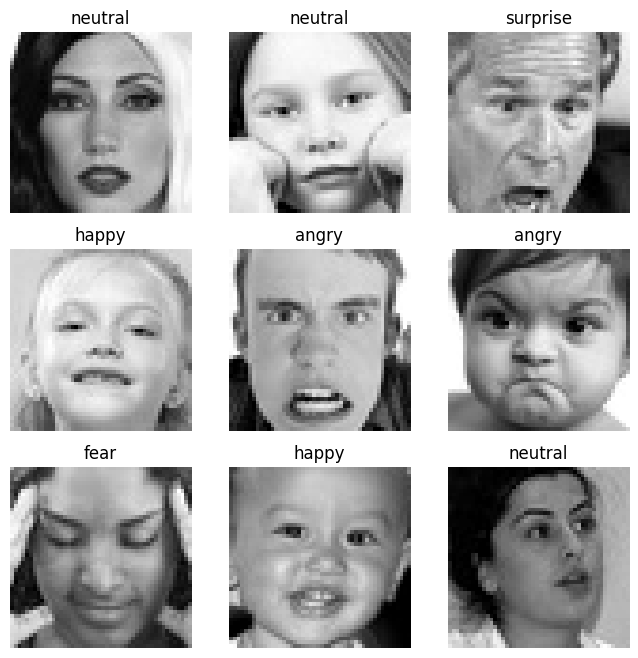

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for images, labels in train_data.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        label_index = tf.argmax(labels[i]).numpy()

        plt.title(
            train_data.class_names[label_index]
        )

        plt.axis("off")

plt.show()

In [11]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

test_data = test_data.map(
    lambda x, y: (normalization_layer(x), y)
)

In [12]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([


    # Layer 1: Convolution


    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(48, 48, 1)
    ),


    # Layer 2: Max Pooling


    MaxPooling2D(
        (2, 2)
    ),


    # Layer 3: Convolution


    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),


    # Layer 4: Max Pooling


    MaxPooling2D(
        (2, 2)
    ),


    # Layer 5: Flatten


    Flatten(),


    # Layer 6: Dense


    Dense(
        128,
        activation="relu"
    ),

    # Prevent overfitting
    Dropout(0.5),


    # Layer 7: Output


    Dense(
        7,
        activation="softmax"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 87s 190ms/step - accuracy: 0.3242 - loss: 1.6987 - val_accuracy: 0.4161 - val_loss: 1.5492
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 86s 192ms/step - accuracy: 0.4135 - loss: 1.5221 - val_accuracy: 0.4614 - val_loss: 1.4173
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 86s 192ms/step - accuracy: 0.4448 - loss: 1.4426 - val_accuracy: 0.4762 - val_loss: 1.3620
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 86s 191ms/step - accuracy: 0.4673 - loss: 1.3832 - val_accuracy: 0.4961 - val_loss: 1.3158
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 87s 193ms/step - accuracy: 0.4877 - loss: 1.3403 - val_accuracy: 0.5063 - val_loss: 1.2860
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 85s 190ms/step - accuracy: 0.5034 - loss: 1.2926 - val_accuracy: 0.5130 - val_loss: 1.2717
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 91s 202ms/step - accuracy: 0.5191 - loss: 1.2666 - val_accuracy: 0.5181 - val_loss: 1.2482
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 85s 190ms/step - accuracy: 0.5333 - loss: 1

In [15]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.5313 - loss: 1.3498
Test Accuracy: 0.531345784664154
Test Accuracy (%): 53.134578466415405


In [16]:
model.save(
    "/content/emotion_model.keras"
)

In [17]:
uploaded = files.upload()

Saving varun_dhawan.jpg to varun_dhawan.jpg


In [20]:
!pip uninstall -y opencv-python opencv-python-headless
!pip install -q opencv-python

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.7 MB/s eta 0:00:00


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,517,143 (9.60 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,678,096 (6.40 MB)

In [24]:
uploaded = files.upload()

Saving varun_dhawan.jpg to varun_dhawan (1).jpg


In [27]:
image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)

if image is None:
    raise ValueError("Could not load image")

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# Resize to CNN input
face = cv2.resize(
    gray,
    (48, 48)
)

# Normalize
face = face.astype(
    np.float32
) / 255.0

# Add batch dimension
face = np.expand_dims(
    face,
    axis=0
)

# Add channel dimension
face = np.expand_dims(
    face,
    axis=-1
)

print("Input shape:", face.shape)

Input shape: (1, 48, 48, 1)


In [29]:
import cv2
import numpy as np

# The class order used by image_dataset_from_directory
class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

# Load your image
image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)

if image is None:
    raise ValueError(f"Could not read image: {image_name}")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Resize to the CNN's expected input size
image_48 = cv2.resize(gray, (48, 48))

# Convert pixel values from 0-255 to 0-1
image_48 = image_48.astype(np.float32) / 255.0

# Shape:
# (48, 48)
#     ↓
# (1, 48, 48, 1)

image_48 = np.expand_dims(image_48, axis=0)
image_48 = np.expand_dims(image_48, axis=-1)

print("Input shape:", image_48.shape)

# MODEL PREDICTION

prediction = model.predict(
    image_48,
    verbose=0
)[0]

# Get the index of the highest probability
predicted_index = np.argmax(prediction)

# Convert index to emotion
predicted_emotion = class_names[predicted_index]

# Get confidence
confidence = prediction[predicted_index] * 100

print("\nPredicted emotion:", predicted_emotion)
print("Confidence:", f"{confidence:.2f}%")

# Show probabilities for every emotion
print("\nAll probabilities:")

for i in range(len(class_names)):
    print(
        f"{class_names[i]:10s}: "
        f"{prediction[i] * 100:.2f}%"
    )

Input shape: (1, 48, 48, 1)

Predicted emotion: happy
Confidence: 81.34%

All probabilities:
angry     : 10.14%
disgust   : 0.00%
fear      : 4.28%
happy     : 81.34%
neutral   : 0.76%
sad       : 3.46%
surprise  : 0.01%


In [30]:
prediction = model.predict(
    face,
    verbose=0
)[0]

predicted_index = np.argmax(
    prediction
)

predicted_emotion = class_names[
    predicted_index
]

confidence = prediction[
    predicted_index
] * 100

print(
    "Predicted emotion:",
    predicted_emotion
)

print(
    "Confidence:",
    f"{confidence:.2f}%"
)

Predicted emotion: happy
Confidence: 81.34%


In [31]:
print("Emotion probabilities:\n")

for emotion, probability in zip(
    class_names,
    prediction
):
    print(
        f"{emotion:10s} : "
        f"{probability * 100:.2f}%"
    )

Emotion probabilities:

angry      : 10.14%
disgust    : 0.00%
fear       : 4.28%
happy      : 81.34%
neutral    : 0.76%
sad        : 3.46%
surprise   : 0.01%


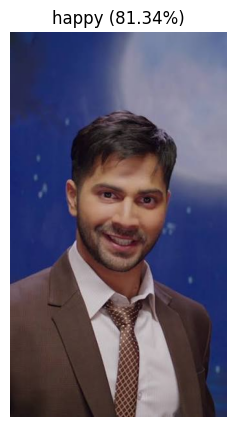

In [34]:
plt.figure(figsize=(5, 5))

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.title(
    f"{predicted_emotion} "
    f"({confidence:.2f}%)"
)

plt.axis("off")

plt.show()